# 05. MCMC で事後分布 (triangle plot) (目標: ベイズ)

01 と同じセットアップ(YAML→モデル、レスポンス畳み込み、観測合成)の上で、
3ML の `BayesianAnalysis` を使って **MCMC サンプリング**し、パラメータの
事後分布の **triangle (corner) plot** を描きます。自由パラメータは
2源のフラックス K と背景 norm。

In [1]:
import logging; logging.disable(logging.INFO)
import numpy as np
import matplotlib.pyplot as plt

from threeML import DataList, BayesianAnalysis
from astromodels import Log_uniform_prior, Uniform_prior
from Toy3MLplugin import (load_sources, simulate_counts, BackgroundComponent,
                      make_folded_response)
from Toy3MLplugin.toy.scanner import ToyScanLike, toy_observation

E_EDGES = np.array([2.0, 10.0]); FOV_SIGMA = 3.0

# レスポンス畳み込み + 観測合成(01と同じ)
R, sky_l, orbit = make_folded_response((0, 30), n_t=500, dwell=200.0,
                                       energy_edges=E_EDGES, fov_sigma_deg=FOV_SIGMA)
n = orbit["l"].size
bkg = lambda: [BackgroundComponent("inst", np.ones(n), value=8.0)]
truth, _ = load_sources("sources.yaml")
sim = ToyScanLike("toy", toy_observation(np.zeros(n), R, sky_l, orbit), E_EDGES, backgrounds=bkg())
data = simulate_counts(sim, truth, np.random.default_rng(0))
plugin = ToyScanLike("toy", toy_observation(data, R, sky_l, orbit), E_EDGES, backgrounds=bkg())

18:48:55 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=5580730;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=5580731;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=5580737;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=5580738;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=5580745;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=5580746;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:48:55 WARNING   WARNINGs here are NOT errors                                                      ]8;id=5580753;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580754;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=5580760;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580761;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#46\46]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=5580796;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580797;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=5580804;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5580805;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=5580811;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580812;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=5580817;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580818;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=5580823;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5580824;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

### 事前分布(prior)を設定して MCMC

In [3]:
m, _ = load_sources("sources.yaml")
m.SRC_A.spectrum.main.Powerlaw.K.prior = Log_uniform_prior(lower_bound=1e-2, upper_bound=1e2)
m.SRC_B.spectrum.main.Powerlaw.K.prior = Log_uniform_prior(lower_bound=1e-2, upper_bound=1e2)
for p in plugin.nuisance_parameters.values():
    p.prior = Uniform_prior(lower_bound=0.0, upper_bound=50.0)

ba = BayesianAnalysis(m, DataList(plugin))
ba.set_sampler("emcee")
ba.sampler.setup(n_walkers=30, n_iterations=1500, n_burn_in=500)
_ = ba.sample()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

Maximum a posteriori probability (MAP) point:

,result,unit
parameter,,
SRC_A.spectrum.main.Powerlaw.K,(9.99 -0.19 +0.18) x 10^-1,1 / (keV s cm2)
SRC_B.spectrum.main.Powerlaw.K,(5.19 -0.15 +0.16) x 10^-1,1 / (keV s cm2)
toy_bkg_inst_norm,7.80 +/- 0.28,


Values of -log(posterior) at the minimum:

,-log(posterior)
toy,28806.002388
total,28806.002388


Values of statistical measures:

,statistical measures
AIC,-57605.956389
BIC,-57593.360952
DIC,-57606.047700
PDIC,2.978613


### 事後分布の triangle (corner) plot

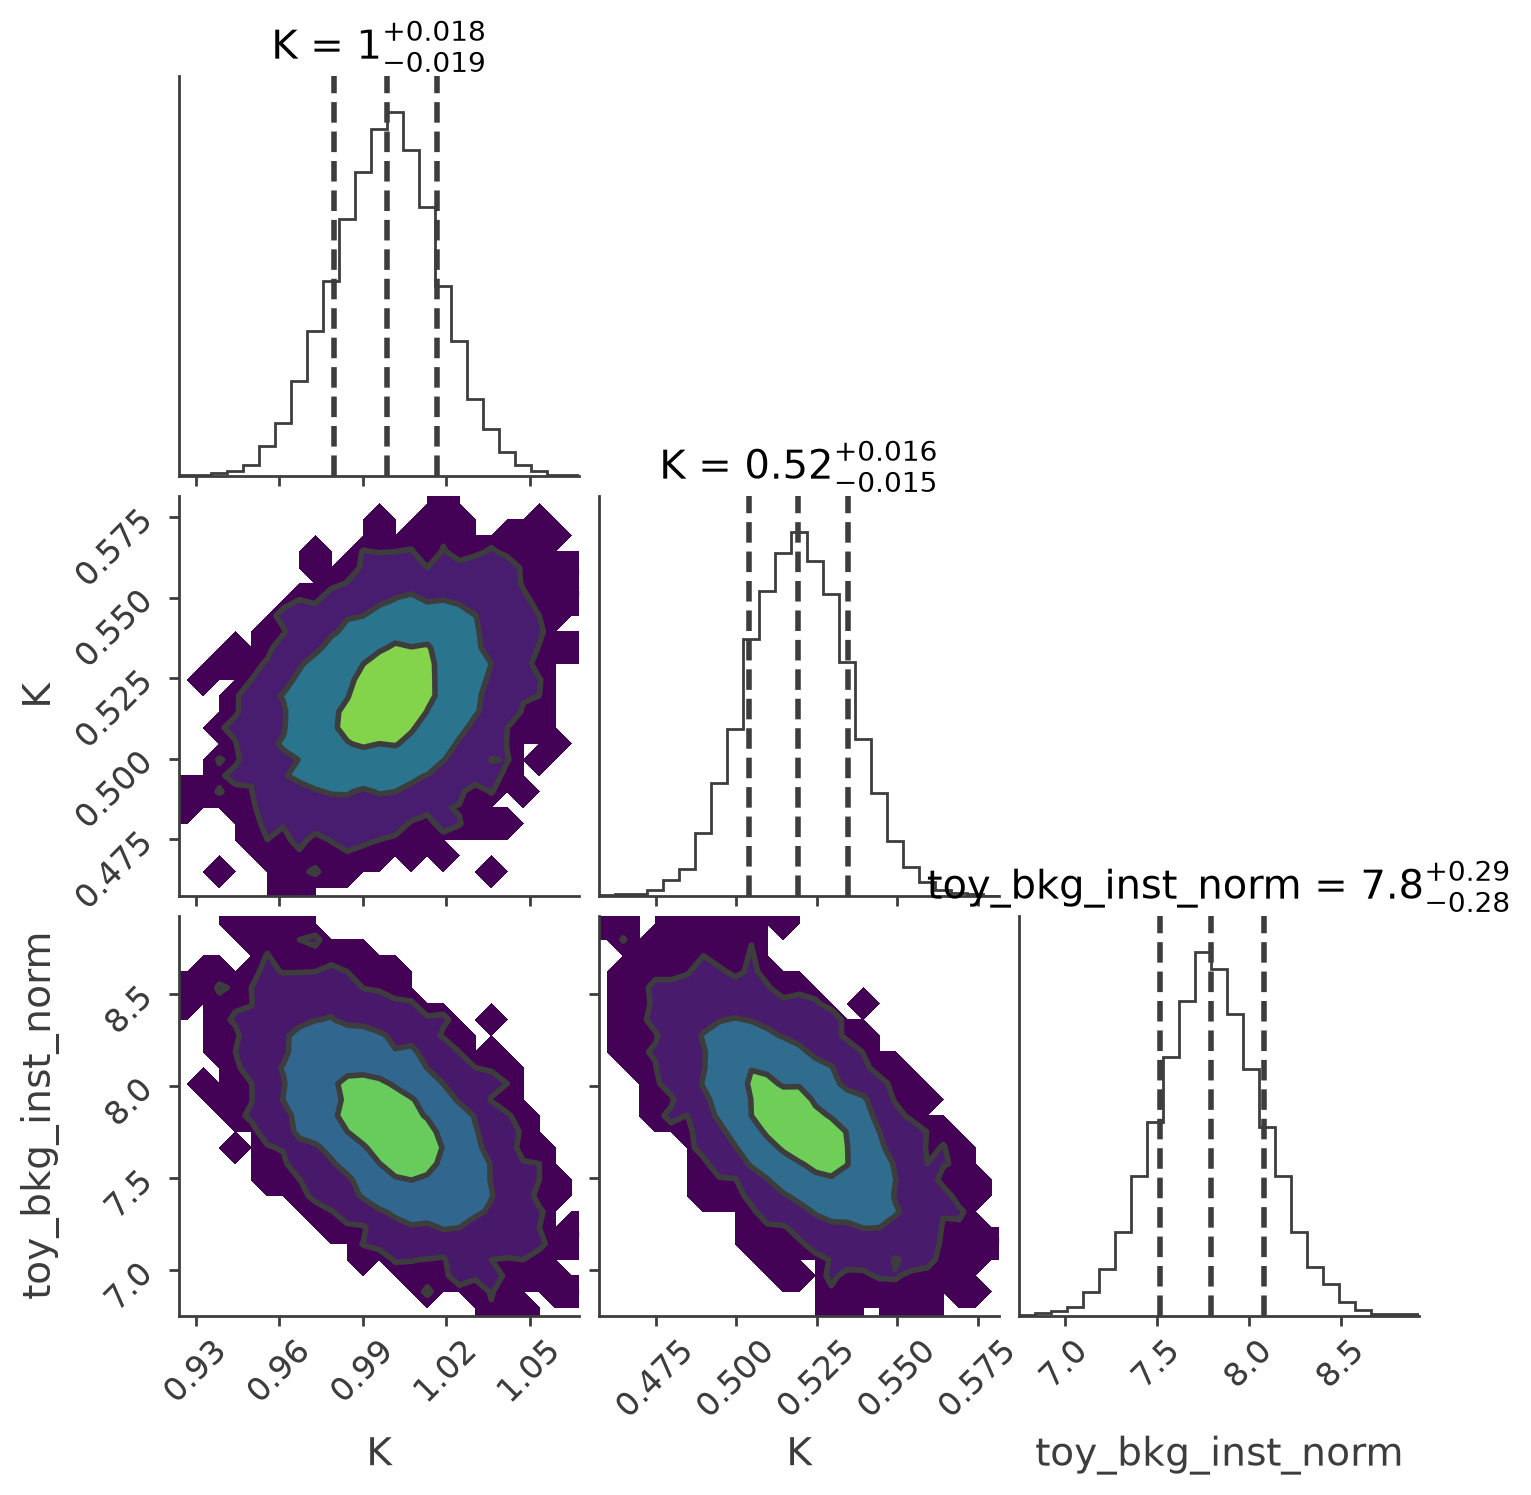

Maximum a posteriori probability (MAP) point:

,result,unit
parameter,,
SRC_A.spectrum.main.Powerlaw.K,(9.99 -0.19 +0.18) x 10^-1,1 / (keV s cm2)
SRC_B.spectrum.main.Powerlaw.K,(5.19 -0.15 +0.16) x 10^-1,1 / (keV s cm2)
toy_bkg_inst_norm,7.80 +/- 0.28,


Values of -log(posterior) at the minimum:

,-log(posterior)
toy,28806.002388
total,28806.002388


Values of statistical measures:

,statistical measures
AIC,-57605.956389
BIC,-57593.360952
DIC,-57606.047700
PDIC,2.978613


In [4]:
fig = ba.results.corner_plot()
plt.show()

ba.results.display()   # 事後の中央値と信頼区間(真値 K=1.0/0.5, bkg=8.0)